### Analysis of Alarm log for Øgreyfoss power plant

This file includes an analysis of the cleaned alarm log dataset, to identify:

- An initial analysis on clean dataset
- Calculation of the number of alarms and warnings, along with their average duration
- Computation of the average acknowledgment time
- An overview of categories and identify the most frequently alarm tags with valid ACK_TS values. The two most common tags were selected and used to extract the corresponding historical data from database.
- Sorting and filtering of the most frequent alarms by duration
- Analysis of communication failures (number, average duration, and total duration)
- Availability analysis (selected tag: OGREY1_G1_KONTROLL_HURTIGSTOPP_MEK_AL)



In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### An initial analysis of the dataset

In [90]:
# get the file_path of the dataset
clean_alarm_data= pd.read_csv(r"E:\Uis Cs\Master thesis\final_project\data\alarmlogg\clean_data\clean_alarm_data.csv")
clean_alarm_data.head(5)   # display the first 5 rows

,ACK_TS,ALARMDESC,CATEGORY,id,TAG,ON_TS,OFF_TS
0,2021-01-05 12:30:39,"Mobilradio (4G) signalstyrke - Høy-høy alarm, 31",NaN,2750460,OGREY1_BILSTDVT_KONTROLL_SIGSTYRK_HH_AL,NaN,2021-01-05 12:30:39
1,2021-01-05 12:30:39,"Mobilradio (4G) signalstyrke - Høy alarm, 31",NaN,2750467,OGREY1_BILSTDVT_KONTROLL_SIGSTYRK_H_AL,NaN,2021-01-05 12:30:39
2,2021-01-05 12:30:39,"Total vannføring vassdrag - Høy-høy alarm, 6,...",NaN,2750451,OGREY1_BILSTDVT_KONTROLL_TOT_VF_HH_AL,NaN,2021-01-05 12:30:39
3,2021-01-05 12:30:33,"Total vannføring vassdrag - Høy alarm, 6,03 m3/s",NaN,2750450,OGREY1_BILSTDVT_KONTROLL_TOT_VF_H_AL,NaN,2021-01-05 12:30:33
4,2021-01-05 12:30:39,"Nivåmåling primærsensor HRV - Høy-høy alarm, 1...",NaN,2750462,OGREY1_BILSTDVT_NIVA_SENSOR_PRI_HRV_HH_AL,NaN,2021-01-05 12:30:39


In [91]:
#get the shape of the dataset
clean_alarm_data.shape

(100000, 7)

In [92]:
# get the name of columns in dataset
clean_alarm_data.columns

Index(['ACK_TS', 'ALARMDESC', 'CATEGORY', 'id', 'TAG', 'ON_TS', 'OFF_TS'], dtype='object')

In [96]:
# Convert the CATEGORY from float to int type
clean_alarm_data['CATEGORY'] = clean_alarm_data['CATEGORY'].astype('Int64')

# The timestamp columns (ACK_TS, ON_TS, and OFF_TS) were converted from object data type to datetime format

clean_alarm_data['ACK_TS'] = pd.to_datetime(clean_alarm_data['ACK_TS'], errors='coerce')
clean_alarm_data['ON_TS'] = pd.to_datetime(clean_alarm_data['ON_TS'], errors='coerce')
clean_alarm_data['OFF_TS'] = pd.to_datetime(clean_alarm_data['OFF_TS'], errors='coerce')

In [95]:
## get the information of the dataset ( feature names, missing value count and data type)

clean_alarm_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   ACK_TS     32710 non-null   datetime64[ns]
 1   ALARMDESC  100000 non-null  object        
 2   CATEGORY   99945 non-null   Int64         
 3   id         100000 non-null  int64         
 4   TAG        100000 non-null  object        
 5   ON_TS      99945 non-null   datetime64[ns]
 6   OFF_TS     99981 non-null   datetime64[ns]
dtypes: Int64(1), datetime64[ns](3), int64(1), object(2)
memory usage: 5.4+ MB


In [48]:
# Rows with missing ON_TS or OFF_TS values were removed before calculating alarm duration

duration_df = clean_alarm_data.dropna(subset=['ON_TS', 'OFF_TS']).copy()

In [49]:
# Alarm starts at ON_TS
# Alarm ends at OFF_TS

(duration_df['OFF_TS'] < duration_df['ON_TS']).sum()

22559

In [50]:
# ACK_TS: Its a timestamp when operator acknowledge an alarm
# Returns the number of rows where ACK_TS is earlier than ON_TS

(duration_df['ACK_TS'] < duration_df['ON_TS']).sum()

114

In [51]:
#finding the rows where the OFF timestamp is earlier than the ON timestamp

duration_df.loc[duration_df['OFF_TS'] < duration_df['ON_TS'],['ON_TS','OFF_TS']].head(10)

,ON_TS,OFF_TS
1500,2025-10-23 12:54:21,2025-10-23 12:54:20
1501,2025-10-23 12:54:21,2025-10-23 12:54:20
1966,2025-09-29 08:29:19,2025-09-29 08:19:15
1967,2025-09-29 08:29:19,2025-09-29 08:29:18
4351,2025-07-20 04:14:04,2025-07-20 04:14:03
4352,2025-07-20 04:14:04,2025-07-20 04:14:03
8639,2025-02-25 08:11:05,2025-02-25 07:47:31
8640,2025-02-25 08:11:05,2025-02-25 08:11:04
8643,2025-02-25 08:03:22,2025-02-25 08:03:20
8644,2025-02-25 08:03:22,2025-02-25 08:03:21


### Calculation of the number of alarms and warnings, along with their average duration
The columns we need for the analysis are: CATEGORY, ON_TS(start time of alarm), OFF_TS (end time of alarm )


In [52]:
#Calculate duration
duration_df['duration_sec'] = (duration_df['OFF_TS'] - duration_df['ON_TS']).dt.total_seconds()

duration_df.loc[duration_df['duration_sec'] < 0, 'duration_sec'].describe().round(2)

count      22559.00
mean       -4938.45
std       121330.95
min     -4709551.00
25%           -1.00
50%           -1.00
75%           -1.00
max           -1.00
Name: duration_sec, dtype: float64

In [53]:
# Counting the valid duratin in second for each category

df_valid = duration_df[duration_df['duration_sec'] >= 0] 
df_valid['CATEGORY'].value_counts()   

CATEGORY
3    62404
2    10822
1     4053
4       90
Name: count, dtype: Int64

In [54]:
# Average duration by listing category in minutes 

avg_duration= df_valid.groupby('CATEGORY')['duration_sec'].mean()/60
print(avg_duration)

CATEGORY
1    1793.492306
2     735.375205
3     453.906717
4     970.813519
Name: duration_sec, dtype: float64


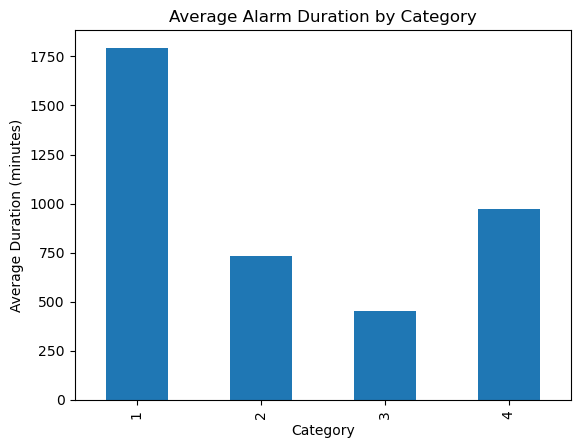

In [55]:
ax = avg_duration.plot(kind='bar')
ax.set_ylabel('Average Duration (minutes)')
ax.set_xlabel('Category')
ax.set_title('Average Alarm Duration by Category')

plt.show()

### Computation of the average acknowledgment time
The columns we need for the analysis are : 

ON_TS = alarm start time 

ACK_TS = Acknowledgement timestemp

In [56]:
duration_df['ack_time_min'] = (duration_df['ACK_TS'] - duration_df['ON_TS']).dt.total_seconds() / 60

In [57]:
# its shows the number of time that ACK_TS, activated before an alarm happen 
(duration_df['ACK_TS'] < duration_df['ON_TS']).sum()

114

In [58]:
ack_df = duration_df[duration_df['ACK_TS'] >= duration_df['ON_TS']].copy()

In [59]:
ack_df['ack_time_min'] = ( ack_df['ACK_TS'] - ack_df['ON_TS']).dt.total_seconds() / 60

ack_df['ack_time_min'].mean()

123.3136719430357

In [61]:
duration_df.loc[duration_df['duration_sec'] < 0, 'duration_sec'].sort_values().head(5)

44633   -4709551.0
44679   -4582869.0
44680   -4582829.0
44707   -4467211.0
44716   -4455748.0
Name: duration_sec, dtype: float64

In [63]:
duration_df.loc[duration_df['duration_sec'] < -60, ['CATEGORY','ALARMDESC','ON_TS','OFF_TS','duration_sec']].head(5)

,CATEGORY,ALARMDESC,ON_TS,OFF_TS,duration_sec
1966,2,Inntak falltap høyt varsel,2025-09-29 08:29:19,2025-09-29 08:19:15,-604.0
8639,3,G1 trafo oljesirkulasjon pumpe aktiv,2025-02-25 08:11:05,2025-02-25 07:47:31,-1414.0
9117,3,G1 stillstand,2025-02-13 08:28:15,2025-02-13 08:07:27,-1248.0
10790,3,G1 generator effektbryter inne,2025-01-15 12:13:35,2025-01-15 11:01:56,-4299.0
10793,3,G1 regulering effekt aktiv,2025-01-15 12:13:35,2025-01-15 11:01:56,-4299.0


### An overview of categories

In [64]:
# Counting the records for each category
# Category 1 indicate Alarms
# Category 2  indicate  Warnings
# Category 3  indicates Events

duration_df['CATEGORY'].value_counts(dropna=False)

CATEGORY
3       84589
2       11040
1        4207
4          92
<NA>        0
Name: count, dtype: Int64

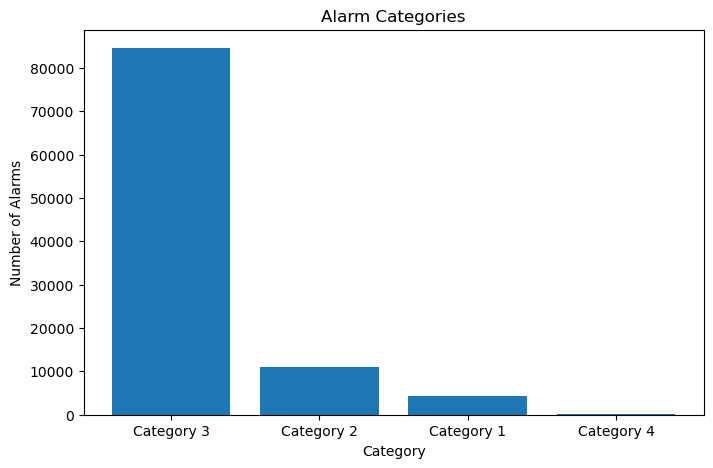

In [65]:

categories= duration_df["CATEGORY"].value_counts().head(5)
labels = [f"Category {x}" for x in categories.index]
plt.figure(figsize=(8,5))

plt.bar(labels, categories)

plt.title("Alarm Categories")       
plt.xlabel("Category")
plt.ylabel("Number of Alarms")

plt.xticks(rotation=0)

plt.show()

In [97]:
# Create a new dataframe containing only rows where ACK_TS has a valid value for analysis
valid_ack_df= duration_df.dropna(subset=['ACK_TS','CATEGORY']).copy()

#analyzing alarm log by year and category
valid_ack_df["year"] = valid_ack_df["ACK_TS"].dt.year
table = pd.crosstab(valid_ack_df["year"], valid_ack_df["CATEGORY"])
table["Total"]=table.sum(axis=1)
table.loc["Total"] = table.sum(axis=0)
print(table)


CATEGORY     1     2      3   4  Total
year                                  
2020        16    11    242   0    269
2021       361   505   5222   8   6096
2022       346   240   2253   0   2839
2023       364   696   4506  19   5585
2024       631   616   7252  18   8517
2025       758  1096   7276   9   9139
2026        36    28    140   0    204
Total     2512  3192  26891  54  32649


In [99]:

top_tags = valid_ack_df[valid_ack_df["CATEGORY"].isin([1])]
filter=top_tags["TAG"].value_counts().head(10)

print(filter)

TAG
OGREY1_G1_KONTROLL_HURTIGSTOPP_MEK_AL         429
OGREY1_INNTAK_RIST_FALLTAP_HH_AL              399
OGREY1_INNTAK_NIVA_OPPSTROM_REF_HRV_HH_AL     328
OGREY1_G1_KONTROLL_NODSTOPP_AL                308
OGREY1_G1_KONTROLL_STOPPSEKVENS_KRITISK_AL    205
OGREY1_G1_KONTROLL_AGC_FELELS_AL              134
OGREY1_G1_GEN_ROTORLOFT_TORRKJORING_AL         95
OGREY1_INNTAK_RIST_FALLTAP_H_KRITISK_AL        69
OGREY1_G1_KONTROLL_HURTIGSTOPP_EL_AL           68
OGREY1_INNTAK_NIVA_OPPSTROM_REF_HRV_LL_AL      65
Name: count, dtype: int64


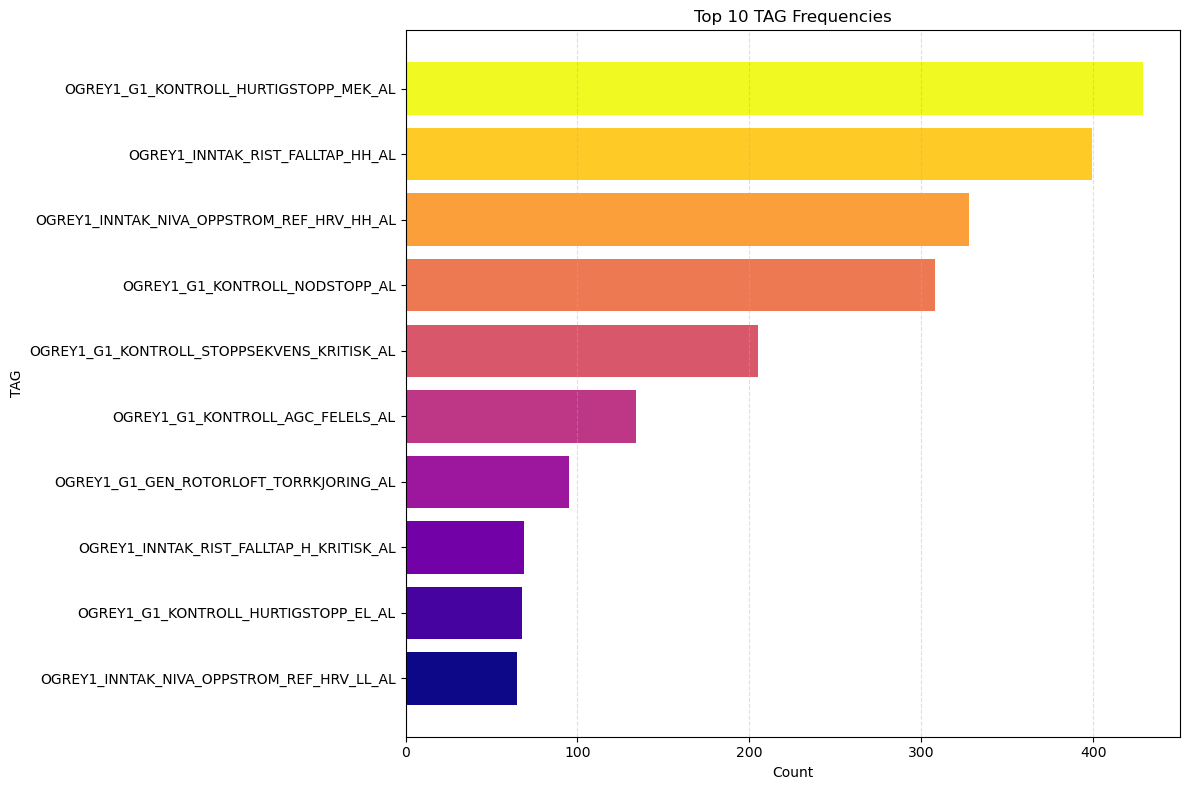

In [106]:

# Create color gradient
colors = plt.cm.plasma(np.linspace(0, 1, len(filter)))

# Plot
plt.figure(figsize=(12,8))

plt.barh(
    filter.index[::-1],      
    filter.values[::-1],
    color=colors
)

plt.xlabel("Count")
plt.ylabel("TAG")
plt.title("Top 10 TAG Frequencies")

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [110]:
# Finding the number of valid ACK_TS records for each year

valid_ack_df["year"] = valid_ack_df["ACK_TS"].dt.year
year_counts = valid_ack_df.groupby("year").size()
print(year_counts)

year
2020     269
2021    6096
2022    2839
2023    5585
2024    8517
2025    9139
2026     204
dtype: int64


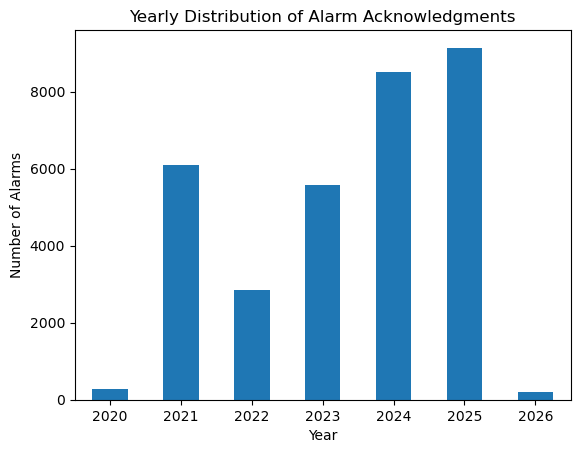

In [109]:
# The figure shows the distribution of valid alarm acknowledgments (ACK_TS) across different year

year_counts.plot(kind="bar")

plt.xlabel("Year")
plt.ylabel("Number of Alarms")
plt.title("Yearly Distribution of Alarm Acknowledgments")

plt.xticks(rotation=0)
plt.show()

### Sorting and filtering of the most frequent alarms by duration

Using TAG, OFF_TS and  ON_TS columns from dataset for finding most frequent alarms  

In [ ]:
# Count of activations for each alarm
top_tags=duration_df['TAG'].value_counts().head(10)
top_tags

TAG
OGREY1_KRST_PUMPEKUM_LENSEPUMP1_DRIFT_AL    39593
OGREY1_INNTAK_RISTRENSK_DRIFT_AL            14553
OGREY1_INNTAK_RISTRENSK_START_PULS_AL       11147
OGREY1_INNTAK_RISTRENSK_FEIL_AL              5408
OGREY1_G1_KONTROLL_STOPPER_AL                2490
OGREY1_G1_KONTROLL_STILLSTAND_AL             2306
OGREY1_G1_KONTROLL_STARTSEKVENS_KLAR_AL      2210
OGREY1_G1_KONTROLL_STARTER_AL                1882
OGREY1_G1_KONTROLL_TOMGANG_AL                1505
OGREY1_G1_TRAFO_OLJE_SIRKPUMPE_AL            1417
Name: count, dtype: int64

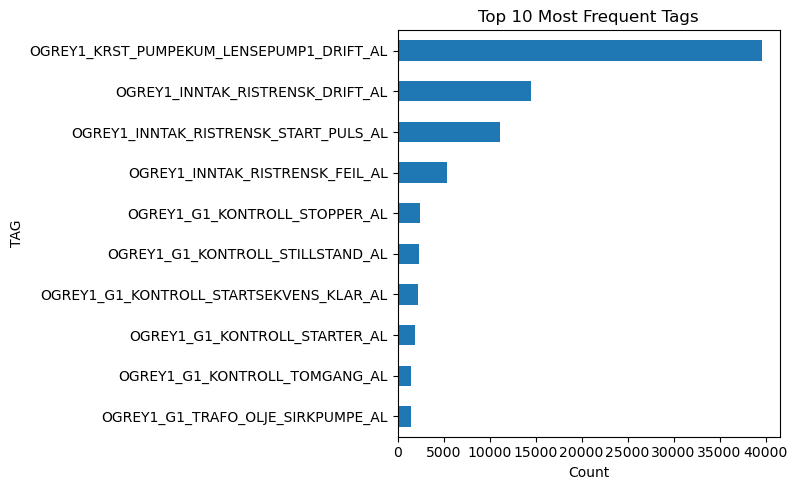

In [72]:

plt.figure(figsize=(8,5))
top_tags.sort_values().plot(kind='barh')

plt.xlabel('Count')
plt.ylabel('TAG')
plt.title('Top 10 Most Frequent Tags')

plt.tight_layout()
plt.show()

In [73]:
# its shows the number of time that OFF_TS, activated before an alarm happen

(duration_df['OFF_TS'] < duration_df['ON_TS']).sum()


22559

In [74]:
valid_t=duration_df[duration_df['OFF_TS'] > duration_df['ON_TS']].copy()

# Calculate duration in hours
valid_t['duration_hours'] = (valid_t['OFF_TS'] - valid_t['ON_TS']).dt.total_seconds() / 3600

# Average duration per alarm tag
avg_duration = (valid_t.groupby('TAG')['duration_hours'].mean().sort_values(ascending=False)).round(2)

print(avg_duration.head(10))

TAG
OGREY1_G1_GEN_VERN_F_KRITISK_AL                        4287.49
OGREY1_G1_GEN_SKILLEBRYTER_INNE_AL                     2800.89
OGREY1_G1_GEN_JORDBRYTER_INNE_AL                       2626.01
OGREY1_KRST_KONTROLL_JOINT_CONTROL_IKKE_AKTIV_AL       2300.11
OGREY1_G1_KJOLEVANN_TRYKK_FORAN_FILTER_L_VARSEL_AL     1171.54
OGREY1_G1_KJOLEVANN_TRYKK_FORAN_FILTER_L_KRITISK_AL    1171.54
OGREY1_INNTAK_RISTRENSK_I_AUTO_AL                       858.52
OGREY1_BOTNAVT_MET_BAROMETER_SLOYFEFEIL_AL              717.55
OGREY1_BOTNAVT_KONTROLL_KOM_AL                          270.01
OGREY1_G1_KONTROLL_STARTSEKVENS_STEG5_KRITISK_AL        246.68
Name: duration_hours, dtype: float64


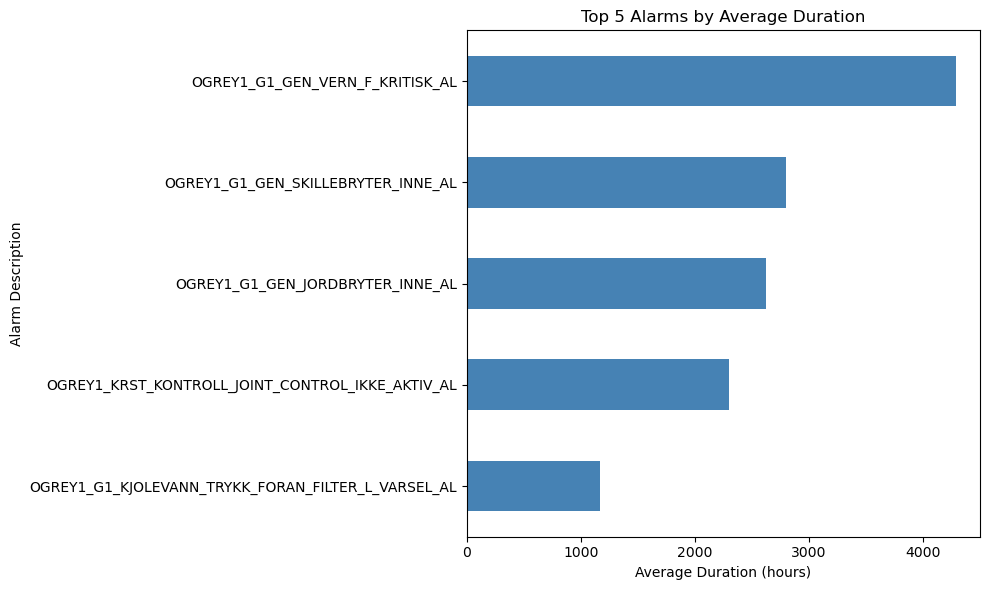

In [75]:
import matplotlib.pyplot as plt

top5 = (valid_t.groupby('TAG')['duration_hours'].mean().sort_values(ascending=False).head(5))

plt.figure(figsize=(10,6))
top5.sort_values().plot(kind='barh',color='steelblue')
plt.xlabel('Average Duration (hours)')
plt.ylabel('Alarm Description')
plt.title('Top 5 Alarms by Average Duration')
plt.tight_layout()

plt.show()

### Analysis of communication failures (number, average duration, and total duration)


In [76]:
duration_df['ALARMDESC'].value_counts().head(10)

ALARMDESC
Kraftstasjon pumpekum lensepumpe 1 i drift      39593
Inntak ristrensker i drift                      14553
Inntak ristrensker start puls tilbakemelding    11147
Inntak ristrensker feil varsel                   5408
G1 stoppsekvens pågår                            2490
G1 stillstand                                    2306
G1 startsekvens klar                             2210
G1 startsekvens pågår                            1882
G1 tomgang                                       1505
G1 trafo oljesirkulasjon pumpe aktiv             1417
Name: count, dtype: int64

In [81]:

comm_df = duration_df[duration_df['ALARMDESC'].str.contains('Kommunikasjon Kommunikasjonsfeil',case=False, na=False)]
len(comm_df)


1332

In [86]:
valid_t=comm_df[comm_df['OFF_TS'] > comm_df['ON_TS']].copy()
valid_t['duration_hours'] = (valid_t['OFF_TS'] - valid_t['ON_TS']).dt.total_seconds() / 3600
valid_t['duration_hours'].mean().round(2)

12.3

In [85]:
valid_t['duration_hours'].sum().round(2)


16093.54

## Availability analysis:
selected Tag: OGREY1_G1_KONTROLL_HURTIGSTOPP_MEK_AL

In [87]:
selected_tag = duration_df[duration_df['TAG'] == 'OGREY1_G1_KONTROLL_HURTIGSTOPP_MEK_AL'].copy()
duration_df['duration_hours'] = (duration_df['OFF_TS'] - duration_df['ON_TS']).dt.total_seconds() / 3600
selected_tag['year'] = selected_tag['ON_TS'].dt.year
downtime_per_year = (selected_tag.groupby('year')['duration_hours'].sum()).round(2)
downtime_per_year

year
2021     537.26
2022    4523.27
2023    2293.44
2024    1161.85
2025     175.12
2026      11.97
Name: duration_hours, dtype: float64

In [88]:
availability = pd.DataFrame({'Downtime (hours)': downtime_per_year,'Availability (%)': ((8760 - downtime_per_year) / 8760) * 100})
availability = availability.drop(2026)  # The year is incomplete
availability['Downtime (hours)'] = availability['Downtime (hours)'].round(2)
availability['Availability (%)'] = availability['Availability (%)'].round(2)
availability


,Downtime (hours),Availability (%)
year,,
2021,537.26,93.87
2022,4523.27,48.36
2023,2293.44,73.82
2024,1161.85,86.74
2025,175.12,98.00
